In [1]:
from thinkbayes import Suite
import thinkbayes

class Euro(Suite):

    def Likelihood(self, data, hypo):
        x = hypo
        if data == 'H':
            return x/100.0
        else:
            return 1 - x/100.0
        
posts = range(1,101)
suite = Euro(posts)
dataset = 'H' * 140 + 'T' * 110

for data in dataset:
    suite.Update(data)

suite.Items()

post = [v for k, v in suite.Items()]

print(suite.Mean())



55.952380952380956


In [2]:
best_hypo, best_prob = max(suite.Items(),
                           key=lambda x: x[1])

print(best_hypo, best_prob)

56 0.12745318058391095


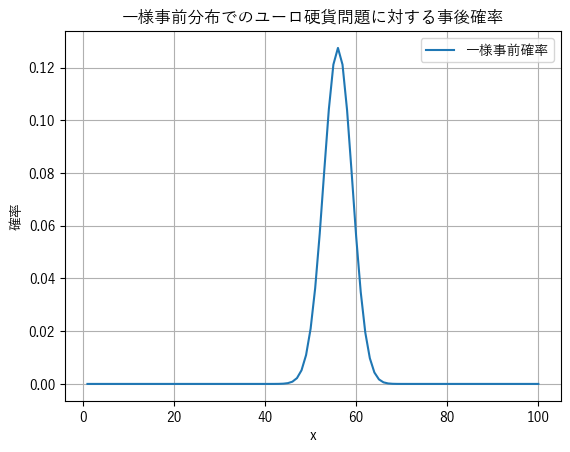

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'YuGothic'

hypos = range(1,101)

plt.plot(hypos, post, label="一様事前確率")

plt.xlabel('x')
plt.ylabel('確率')

plt.title('一様事前分布でのユーロ硬貨問題に対する事後確率')
plt.legend()
plt.grid(True)
    

In [4]:
Median = thinkbayes.Percentile(suite, 50)
print(Median)

56


In [7]:
ci = thinkbayes.CredibleInterval(suite, 90)
print(ci)

(51, 61)
